# Importación de librerías

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import glob
import cv2
import splitfolders
import shutil

import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers

from sklearn import svm
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import  accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight


Montar el drive y cargar el dataset.

In [ ]:
import os
import tensorflow as tf

# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\EVENODD'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\ODD'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\EVEN'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\GROUP09'
root_dir = r'C:\Users\TU_RUTA_AL_DATASET\KAGGLE'

train_folder = os.path.join(root_dir, "train")
val_folder   = os.path.join(root_dir, "val")
test_folder  = os.path.join(root_dir, "test")

# Parámetros
batch_size = 32
img_height = 224
img_width = 224
dropout_rate = 0.5
epochs = 40
num_classes = 6

train_ds = tf.keras.utils.image_dataset_from_directory(
  train_folder,
  seed = 123,
  image_size = (img_height, img_width),
  batch_size = batch_size,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  val_folder,
  seed=123,
  image_size=(img_height, img_width),
  batch_size = batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_folder,
    seed = 123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print(class_names)

Found 6455 files belonging to 6 classes.
Found 1077 files belonging to 6 classes.
Found 1390 files belonging to 6 classes.
['cups', 'forks', 'glasses', 'knives', 'plates', 'spoons']


Creamos el training, validation y test dataset

Imprimir 9 imágenes del dataset

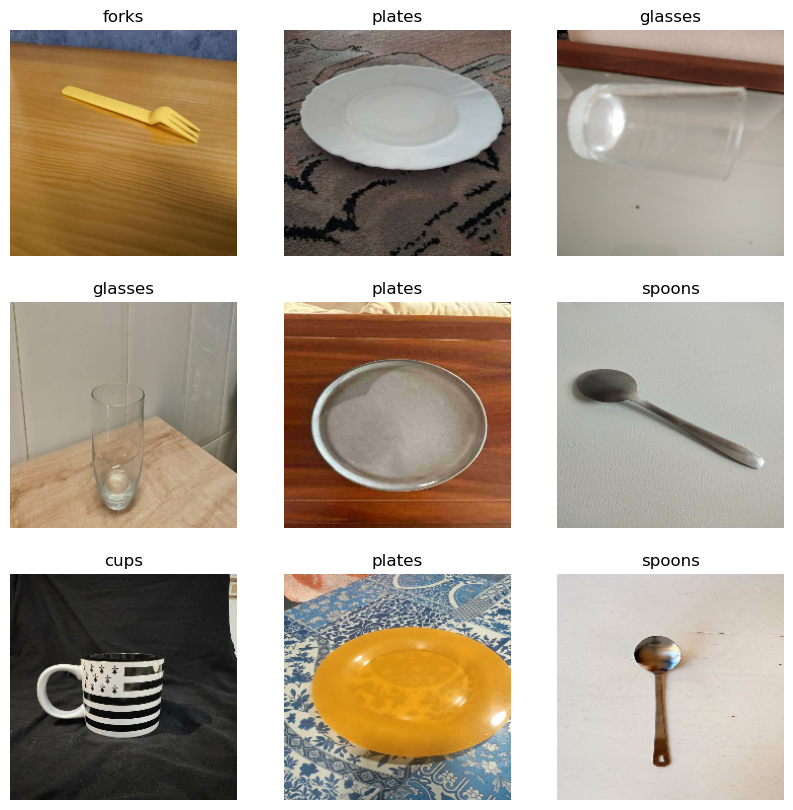

In [39]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

Arquitectura

In [24]:
import tensorflow as tf

class SparseF1Score(tf.keras.metrics.F1Score):
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.int32) 
        y_true = tf.reshape(y_true, [-1]) # aplanar a 1D
        num_classes = tf.shape(y_pred)[-1] 
        y_true_one_hot = tf.one_hot(y_true, depth=num_classes) # convertir a One-Hot
        return super().update_state(y_true_one_hot, y_pred, sample_weight) # pasar los datos al F1Score original

Data Augmentation

In [25]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomContrast(0.3),
    layers.RandomBrightness(0.1)
])

In [43]:
class EfficientNetTransfer:
    def __init__(self, input_shape, num_classes, model_variant='B0'):
        self.num_classes = num_classes
        self.input_shape = input_shape
        self.model_variant = model_variant
        self.class_weight_dict = None
        self._build_model()

    def _build_model(self):
        inputs = keras.Input(shape=self.input_shape)
        x = data_augmentation(inputs)
        x = keras.applications.efficientnet.preprocess_input(x)

        base_model = keras.applications.EfficientNetB0(
            input_shape=self.input_shape,
            include_top=False,
            weights='imagenet'
        )

        base_model.trainable = False
        self.base_model = base_model

        x = base_model(x, training=False)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        outputs = layers.Dense(self.num_classes, activation='softmax')(x)

        self.model = keras.Model(inputs, outputs)
        self.model.summary()

    def compute_class_weights(self, dataset):

        y_all = np.concatenate([y.numpy() for _, y in dataset], axis=0)

        weights = compute_class_weight(
            class_weight='balanced',
            classes=np.arange(self.num_classes),
            y=y_all
        )
        self.class_weight_dict = dict(enumerate(weights))

        print("Class weights calculados:")
        for cls, w in self.class_weight_dict.items():
            print(f"  Clase {cls}: {w:.4f}")

        return self.class_weight_dict

    def compile_phase1(self, lr=1e-3):
        self.model.compile(
            optimizer=keras.optimizers.Adam(lr),
            loss=keras.losses.SparseCategoricalCrossentropy(),
            metrics=['accuracy', SparseF1Score(average='weighted', name='f1_score')]
        )

    def unfreeze_top_layers(self, num_layers=40):
        self.base_model.trainable = True
        for layer in self.base_model.layers[:-num_layers]:
            layer.trainable = False
        trainable = sum(1 for l in self.base_model.layers if l.trainable)
        print(f"Capas entrenables en backbone: {trainable} / {len(self.base_model.layers)}")

    def compile_phase2(self, lr=1e-5):
        self.model.compile(
            optimizer=keras.optimizers.Adam(lr),
            loss=keras.losses.SparseCategoricalCrossentropy(),
            metrics=['accuracy', SparseF1Score(average='weighted', name='f1_score')]
        )

    def fit_model(self, epochs_phase1=15, epochs_phase2=25):
        if self.class_weight_dict is None:
            print(" Continuando sin class weights...\n")

        callbacks = [
            keras.callbacks.ReduceLROnPlateau(
            monitor='val_f1_score', factor=0.5,
            patience=4, min_lr=1e-7,
            mode='max',
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_f1_score',
            patience=8,
            restore_best_weights=True,
            mode='max',
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            'best_model.keras',
            monitor='val_f1_score',
            save_best_only=True,
            mode='max',
            verbose=1
        )
        ]

        print("\n Fase 1: entrenando solo la cabeza")
        self.compile_phase1(lr=1e-3)
        self.history_p1 = self.model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=epochs_phase1,
            callbacks=callbacks,
            class_weight=self.class_weight_dict
        )

        print("\n Fase 2: fine-tuning capas superiores")
        self.unfreeze_top_layers(num_layers=20)
        self.compile_phase2(lr=1e-5)
        self.history_p2 = self.model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=epochs_phase2,
            callbacks=callbacks,
            initial_epoch=len(self.history_p1.epoch),
            class_weight=self.class_weight_dict
        )

    def plots(self):
        acc  = self.history_p1.history['accuracy']  + self.history_p2.history['accuracy']
        vacc = self.history_p1.history['val_accuracy'] + self.history_p2.history['val_accuracy']
        loss  = self.history_p1.history['loss']  + self.history_p2.history['loss']
        vloss = self.history_p1.history['val_loss'] + self.history_p2.history['val_loss']
        sep = len(self.history_p1.epoch)

        epochs_range = range(len(acc))

        plt.figure(figsize=(8, 8))

        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, acc,  label='Train Accuracy')
        plt.plot(epochs_range, vacc, label='Val Accuracy')
        plt.axvline(sep, color='gray', linestyle='--', label='Fine-tune start')
        plt.legend(loc='lower right')
        plt.title('Accuracy')
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, loss,  label='Train Loss')
        plt.plot(epochs_range, vloss, label='Val Loss')
        plt.axvline(sep, color='gray', linestyle='--', label='Fine-tune start')
        plt.legend(loc='upper right')
        plt.title('Loss')
        plt.grid(True)


        plt.tight_layout()
        plt.savefig('training_curves.png', dpi=120)
        plt.show()

    def get_predictions(self, dataset):
        y_true, y_pred, images_list = [], [], []
        for images, labels in dataset:
            preds = self.model.predict(images, verbose=0)
            y_pred.extend(np.argmax(preds, axis=1))
            y_true.extend(labels.numpy())
            images_list.extend(images.numpy())
        return np.array(y_true), np.array(y_pred), np.array(images_list)

    def evaluate(self):
        print("\n Evaluación en Test ")
        results = self.model.evaluate(test_ds, verbose=1)
        for name, val in zip(self.model.metrics_names, results):
            print(f"  {name}: {val:.4f}")

    def plot_confusion_matrix(self, y_true, y_pred, class_names):
        cm = confusion_matrix(y_true, y_pred)
        cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_title('Confusion Matrix (normalized)')
        ax.set_ylabel('True label')
        ax.set_xlabel('Predicted label')
        plt.tight_layout()
        plt.savefig('confusion_matrix.png', dpi=120)
        plt.show()

    def plot_misclassified(self, y_true, y_pred, images, class_names, n=12):
        wrong_idx = np.where(y_true != y_pred)[0]
        print(f'Total mal clasificadas: {len(wrong_idx)} / {len(y_true)}')

        show = wrong_idx[:n]
        cols = 4
        rows = int(np.ceil(len(show) / cols))

        fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
        axes = axes.flatten()

        for i, idx in enumerate(show):
            img = images[idx].astype('uint8')
            axes[i].imshow(img)
            axes[i].set_title(
                f'True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}',
                color='red', fontsize=10)
            axes[i].axis('off')

        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle('Imágenes mal clasificadas', fontsize=13)
        plt.tight_layout()
        plt.savefig('misclassified.png', dpi=120)
        plt.show()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_24 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Class weights calculados:
  Clase 0: 0.7550
  Clase 1: 1.7104
  Clase 2: 1.2993
  Clase 3: 1.0111
  Clase 4: 0.7773
  Clase 5: 0.9563

 Fase 1: entrenando solo la cabeza
Epoch 1/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.8349 - f1_score: 0.8360 - loss: 0.4938
Epoch 1: val_f1_score improved from None to 0.95931, saving model to best_model.keras
202/202 ━━━━━━━━━━━━━━━━━━━━ 70s 308ms/step - accuracy: 0.8962 - f1_score: 0.8968 - loss: 0.3281 - val_accuracy: 0.9526 - val_f1_score: 0.9593 - val_loss: 0.1803 - learning_rate: 0.0010
Epoch 2/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.9339 - f1_score: 0.9339 - loss: 0.2111
Epoch 2: val_f1_score improved from 0.95931 to 0.96302, saving model to best_model.keras
202/202 ━━━━━━━━━━━━━━━━━━━━ 59s 293ms/step - accuracy: 0.9352 - f1_score: 0.9353 - loss: 0.2036 - val_accuracy: 0.9573 - val_f1_score: 0.9630 - val_loss: 0.1800 - learning_rate: 0.0010
Epoch 3/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.9

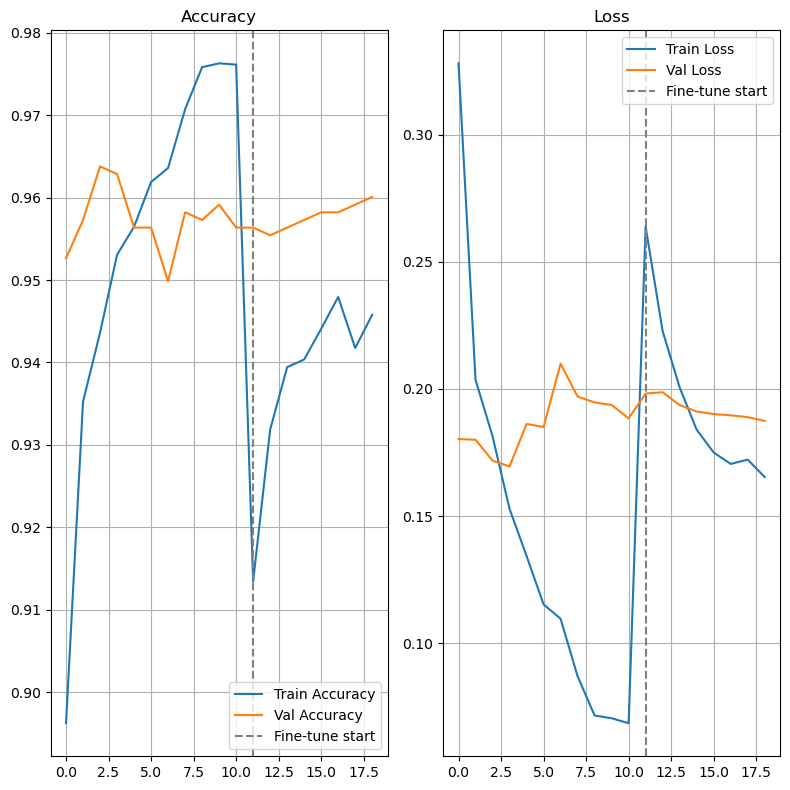


 Evaluación en Test 
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 259ms/step - accuracy: 0.9309 - f1_score: 0.9311 - loss: 0.2350
  loss: 0.2350
  compile_metrics: 0.9309


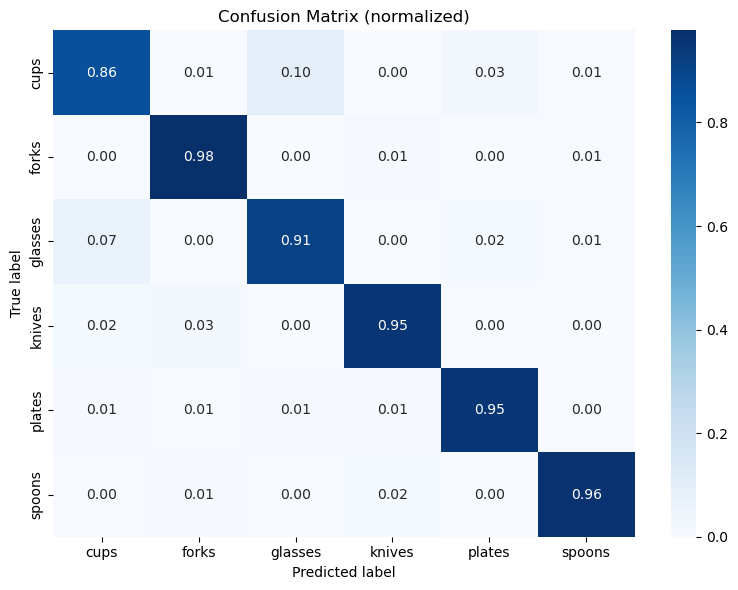

Total mal clasificadas: 96 / 1390


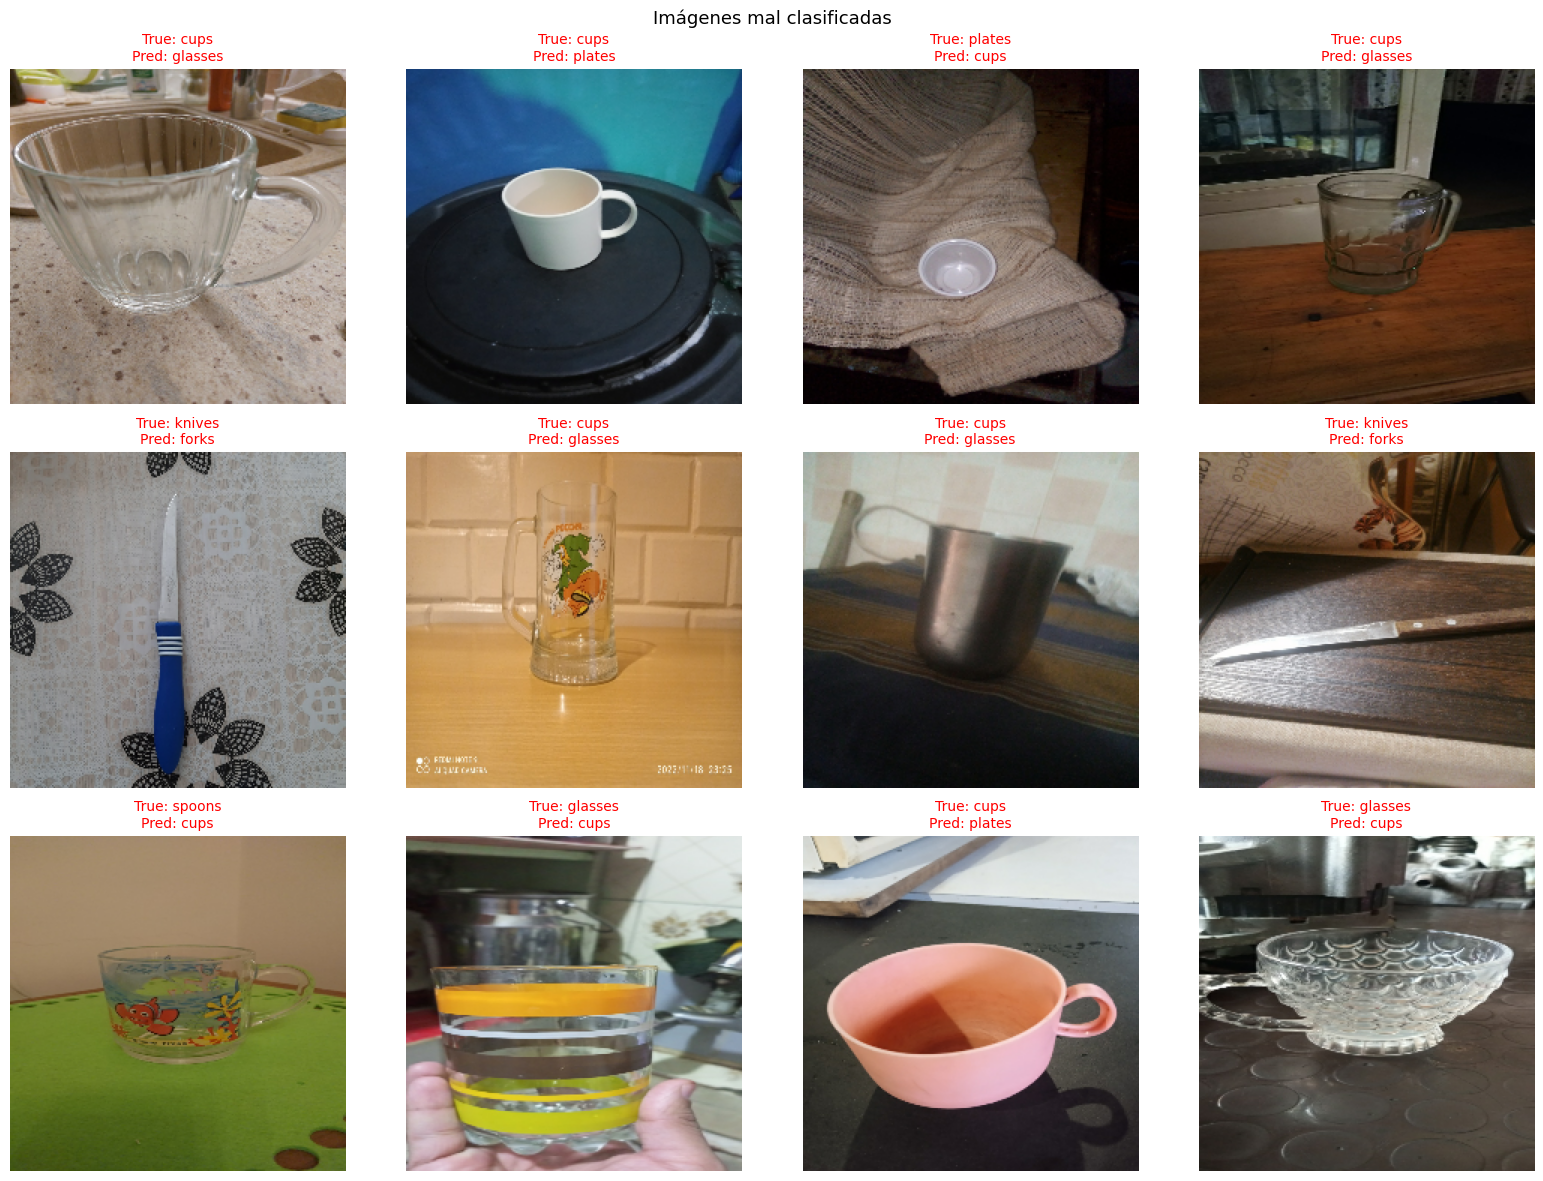

In [44]:
if __name__ == '__main__':
    model = EfficientNetTransfer(
        input_shape=(img_height, img_width, 3),
        num_classes=num_classes,
        model_variant='B0'
    )
    model.compute_class_weights(train_ds)
    model.fit_model(epochs_phase1=15, epochs_phase2=25)
    model.plots()
    model.evaluate()
    y_true, y_pred, images_arr = model.get_predictions(test_ds)
    model.plot_confusion_matrix(y_true, y_pred, class_names)
    model.plot_misclassified(y_true, y_pred, images_arr, class_names, n=12)